In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
import matplotlib
from scipy.interpolate import RegularGridInterpolator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
import os
from datetime import datetime

# Folder containing the CSV exports from "Strain Simulation FEniCSx.ipynb".
# All coordinates in these files are already in the exported convention:
# x = mesh_x - 1.25, y = mesh_y - 108.05, z = -z_mesh - 13 (Ge well: z = 42-58).
# Do NOT shift the data again after loading.
SIM_DIR = "simulation_2026-09-08"

# All PDF graphs are saved into graph/<date>/ (created if missing)
GRAPH_DIR = os.path.join("graph", datetime.now().strftime("%Y-%m-%d"))
os.makedirs(GRAPH_DIR, exist_ok=True)

# Load Strain Data

In [2]:
# Load the 3D strain data from the FEniCSx export. The coordinates in these
# CSVs are already in the exported convention (data x = mesh_x - 1.25,
# y = mesh_y - 108.05, z = -z_mesh - 13), so NO shift is applied here.
strain_files = {
    'strain_yymxx': f"{SIM_DIR}/strain_3D/strain_yy-xx_3D.csv",
    'strain_xz': f"{SIM_DIR}/strain_3D/strain_xz_3D.csv",
    'strain_yz': f"{SIM_DIR}/strain_3D/strain_yz_3D.csv",
    'strain_xy': f"{SIM_DIR}/strain_3D/strain_xy_3D.csv",
    'strain_zz': f"{SIM_DIR}/strain_3D/strain_zz_3D.csv",
    'strain_yypxx': f"{SIM_DIR}/strain_3D/strain_yy+xx_3D.csv"
}

# Load the data into a dictionary of dataframes
strain_data = {name: pd.read_csv(path) for name, path in strain_files.items()}

In [3]:
# Write constants for calculating the g-factor correction
b = -2.160
k = 3.410
d = -6.060

# Delta_LH Calculation

In [4]:
# Define a function to compute the LH-HH band gap
def compute_LH_HH_gap(constant_term, strain_yypxx, strain_zz):
    """
    Calculate the LH-HH band gap using the given constant term and strain components.

    Parameters:
    constant_term (float): The constant term in the gap equation.
    strain_yypxx (DataFrame): The strain data for (ε_xx + ε_yy).
    strain_zz (DataFrame): The strain data for ε_zz.

    Returns:
    gap (DataFrame): The calculated LH-HH band gap distribution.
    """
    # Calculate the second term: (ε_xx + ε_yy) - 2 * ε_zz
    second_term = strain_yypxx['strain_value'] - 2 * strain_zz['strain_value']

    # Compute the total LH-HH band gap
    gap = constant_term + b * second_term

    return gap

# Define the constant term
constant_term = 24.912 * 10 ** (-3)

# Sort the strain dataframes by 'z', 'y', and 'x' for correct reshaping
strain_yypxx_sorted = strain_data['strain_yypxx'].sort_values(by=['z', 'y', 'x'])
strain_zz_sorted = strain_data['strain_zz'].sort_values(by=['z', 'y', 'x'])

# Update the calculation to use the sorted 3D data
delta_LH_HH_gap = compute_LH_HH_gap(constant_term, strain_yypxx_sorted, strain_zz_sorted)

# Create a new DataFrame that includes x, y, z, and delta_LH_HH_gap
result_data = strain_yypxx_sorted[['x', 'y', 'z']].copy()
result_data['delta_LH_HH_gap'] = delta_LH_HH_gap.values

# Convert the result to a NumPy array with x, y, z, and delta_LH_HH_gap as columns
result_array = result_data.to_numpy()

# Print the head of the result array for a quick check
print(result_data.head())


                x       y     z  delta_LH_HH_gap
0     -501.250000 -518.05  42.0         0.025059
9000  -497.905518 -518.05  42.0         0.025231
18000 -494.561037 -518.05  42.0         0.025403
27000 -491.216555 -518.05  42.0         0.025575
36000 -487.872074 -518.05  42.0         0.025472


                x       y          z  delta_LH_HH_gap
4     -501.250000 -518.05  44.206897         0.024630
9004  -497.905518 -518.05  44.206897         0.025136
18004 -494.561037 -518.05  44.206897         0.025308
27004 -491.216555 -518.05  44.206897         0.025237
36004 -487.872074 -518.05  44.206897         0.025326


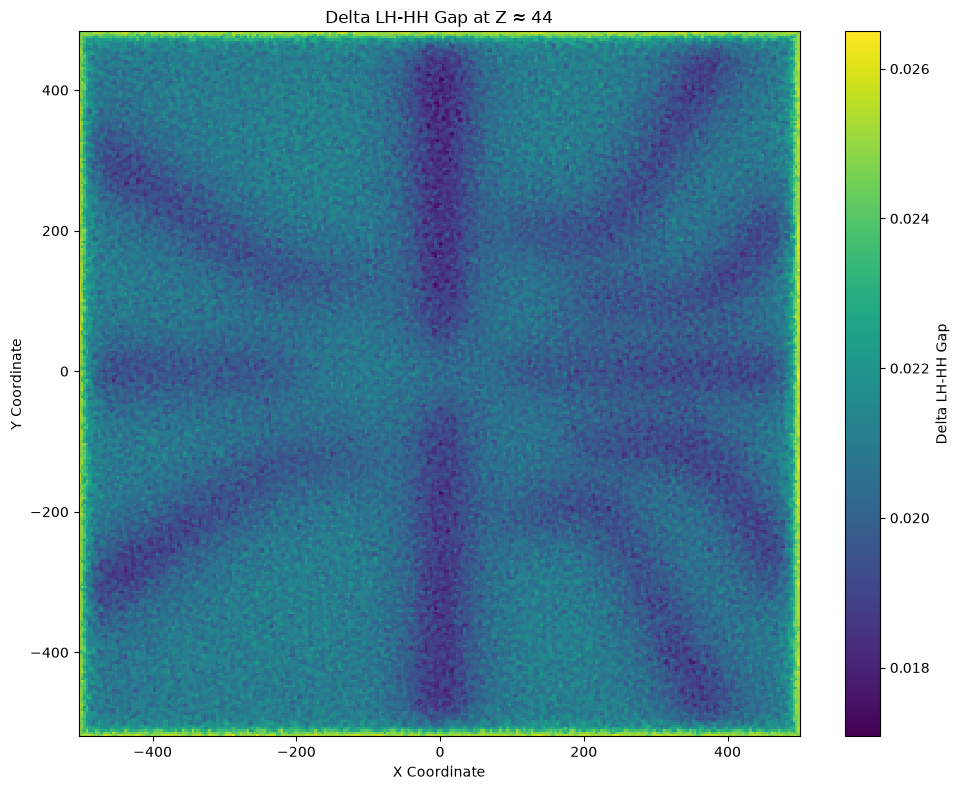

In [5]:
# Define tolerance
z_tolerance = 0.3

# Extract the data for z close to 44
z_close_to_44_data = result_data[(result_data['z'] >= 44 - z_tolerance) & (result_data['z'] <= 44 + z_tolerance)]

# Print the head of the data for z close to 44 for a quick check
print(z_close_to_44_data.head())

# Create a new DataFrame with only x, y, and delta_LH_HH_gap columns for plotting
xy_gap_data = z_close_to_44_data[['x', 'y', 'delta_LH_HH_gap']]
plt.figure(figsize=(10, 8))

# Create a grid to use for pcolormesh
x_unique = np.sort(xy_gap_data['x'].unique())
y_unique = np.sort(xy_gap_data['y'].unique())
x_mesh, y_mesh = np.meshgrid(x_unique, y_unique)

# Use pivot to create a 2D grid of the delta_LH_HH_gap values
xy_gap_pivot = xy_gap_data.pivot(index='y', columns='x', values='delta_LH_HH_gap')

# Fill in NaN values if they exist, to prevent plotting issues
xy_gap_pivot_filled = xy_gap_pivot.fillna(0).values

# Plot using pcolormesh
plt.pcolormesh(x_mesh, y_mesh, xy_gap_pivot_filled, cmap='viridis', shading='auto')
plt.colorbar(label='Delta LH-HH Gap')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Delta LH-HH Gap at Z ≈ 44')
plt.tight_layout()
plt.show()


# g-Tensor Correction (δg) Calculation

In [6]:
# Define the function to calculate the site-dependent δg_xx (and δg_yy) g-tensor correction
def delta_g_xx_func(eps_yymxx, delta_LH):
    """
    Calculate the δg_xx g-tensor correction using the strain components and site-dependent delta_LH.

    Parameters:
    eps_yymxx (array-like): Strain component (ε_yy − ε_xx).
    delta_LH (array-like): Site-dependent LH-HH band gap.

    Returns:
    delta_g_xx (array-like): δg_xx correction for each site.
    """
    delta_g_xx = (6 * b * k * eps_yymxx) / delta_LH
    return delta_g_xx

# Define the function to calculate the site-dependent δg_zx g-tensor correction
def delta_g_zx_func(eps_xz, delta_LH):
    """
    Calculate the δg_zx g-tensor correction using the strain components and site-dependent delta_LH.

    Parameters:
    eps_xz (array-like): Strain component ε_xz.
    delta_LH (array-like): Site-dependent LH-HH band gap.

    Returns:
    delta_g_zx (array-like): δg_zx correction for each site.
    """
    delta_g_zx = (-4 * np.sqrt(3) * d * k * eps_xz) / delta_LH
    return delta_g_zx

# Define the function to calculate the site-dependent δg_zy g-tensor correction
def delta_g_zy_func(eps_yz, delta_LH):
    """
    Calculate the δg_zy g-tensor correction using the strain components and site-dependent delta_LH.

    Parameters:
    eps_yz (array-like): Strain component ε_yz.
    delta_LH (array-like): Site-dependent LH-HH band gap.

    Returns:
    delta_g_zy (array-like): δg_zy correction for each site.
    """
    delta_g_zy = (-4 * np.sqrt(3) * d * k * eps_yz) / delta_LH
    return delta_g_zy

# Define the function to calculate the site-dependent δg_xy g-tensor correction
def delta_g_xy_func(eps_xy, delta_LH):
    """
    Calculate the δg_xy g-tensor correction using the strain components and site-dependent delta_LH.

    Parameters:
    eps_xy (array-like): Strain component ε_xy.
    delta_LH (array-like): Site-dependent LH-HH band gap.

    Returns:
    delta_g_xy (array-like): δg_xy correction for each site.
    """
    delta_g_xy = (4 * np.sqrt(3) * d * k * eps_xy) / delta_LH
    return delta_g_xy

# Create a new DataFrame for δg_xx correction values and coordinates using site-dependent delta_LH
delta_g_xx_data = pd.DataFrame({
    'x': strain_data['strain_yymxx']['x'],
    'y': strain_data['strain_yymxx']['y'],
    'z': strain_data['strain_yymxx']['z'],
    'delta_g_xx': delta_g_xx_func(strain_data['strain_yymxx']['strain_value'], result_data['delta_LH_HH_gap'])
})

# Create a new DataFrame for δg_zx correction values and coordinates using site-dependent delta_LH
delta_g_zx_data = pd.DataFrame({
    'x': strain_data['strain_xz']['x'],
    'y': strain_data['strain_xz']['y'],
    'z': strain_data['strain_xz']['z'],
    'delta_g_zx': delta_g_zx_func(strain_data['strain_xz']['strain_value'], result_data['delta_LH_HH_gap'])
})

# Create a new DataFrame for δg_zy correction values and coordinates using site-dependent delta_LH
delta_g_zy_data = pd.DataFrame({
    'x': strain_data['strain_yz']['x'],
    'y': strain_data['strain_yz']['y'],
    'z': strain_data['strain_yz']['z'],
    'delta_g_zy': delta_g_zy_func(strain_data['strain_yz']['strain_value'], result_data['delta_LH_HH_gap'])
})

# Create a new DataFrame for δg_xy correction values and coordinates using site-dependent delta_LH
delta_g_xy_data = pd.DataFrame({
    'x': strain_data['strain_xy']['x'],
    'y': strain_data['strain_xy']['y'],
    'z': strain_data['strain_xy']['z'],
    'delta_g_xy': delta_g_xy_func(strain_data['strain_xy']['strain_value'], result_data['delta_LH_HH_gap'])
})

          x           y          z  delta_g_zy
4   -501.25 -518.050000  44.206897   -1.215824
34  -501.25 -514.705518  44.206897   -0.941473
64  -501.25 -511.361037  44.206897   -0.337409
94  -501.25 -508.016555  44.206897    0.157192
124 -501.25 -504.672074  44.206897    0.127360


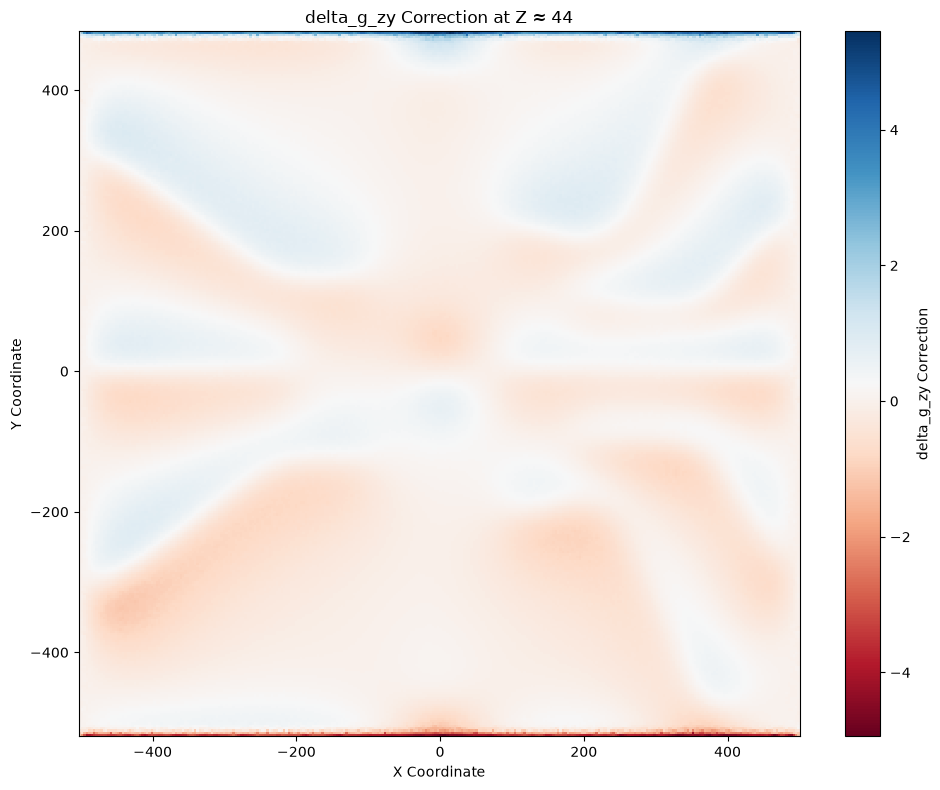

In [7]:
# Function to plot the selected g-tensor correction component
def plot_delta_g_component(delta_g_data, component, z_value, z_tolerance=0.3):
    """
    Plot the specified g-tensor correction component at a given z-value.

    Parameters:
    delta_g_data (dict): Dictionary containing the g-tensor correction (δg) dataframes (e.g., delta_g_xx_data, delta_g_xy_data).
    component (str): The g-tensor correction component to plot (e.g., 'delta_g_xx', 'delta_g_xy', 'delta_g_zx', 'delta_g_zy').
    z_value (float): The z-coordinate to focus on.
    z_tolerance (float): Tolerance for selecting data near the z-coordinate.
    """
    # Select the appropriate dataframe based on the component
    if component not in delta_g_data:
        raise ValueError(f"Invalid component '{component}'. Must be one of: {list(delta_g_data.keys())}")

    # Extract the data for the given z-value within the tolerance
    selected_data = delta_g_data[component][
        (delta_g_data[component]['z'] >= z_value - z_tolerance) &
        (delta_g_data[component]['z'] <= z_value + z_tolerance)
    ]

    # Print the head of the data for a quick check
    print(selected_data.head())

    # Create a new DataFrame with only x, y, and the selected component's values for plotting
    plot_data = selected_data[['x', 'y', component]]

    # Plot x, y, and the selected component's values using a colormap
    plt.figure(figsize=(10, 8))

    # Create a grid to use for pcolormesh
    x_unique = np.sort(plot_data['x'].unique())
    y_unique = np.sort(plot_data['y'].unique())
    x_mesh, y_mesh = np.meshgrid(x_unique, y_unique)

    # Use pivot to create a 2D grid of the component's values
    pivot_data = plot_data.pivot(index='y', columns='x', values=component)

    # Fill in NaN values if they exist, to prevent plotting issues
    pivot_filled = pivot_data.fillna(0).values

    # Plot using pcolormesh
    plt.pcolormesh(x_mesh, y_mesh, pivot_filled, cmap='RdBu', shading='auto')
    plt.colorbar(label=f'{component} Correction')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(f'{component} Correction at Z ≈ {z_value}')
    plt.tight_layout()
    plt.show()

# Example Usage:
# Dictionary containing all g-tensor dataframes
delta_g_data = {
    'delta_g_xx': delta_g_xx_data,
    'delta_g_xy': delta_g_xy_data,
    'delta_g_zx': delta_g_zx_data,
    'delta_g_zy': delta_g_zy_data
}

# Specify the component, z-value, and tolerance
component_to_plot = 'delta_g_zy'  # Options: 'delta_g_xx', 'delta_g_xy', 'delta_g_zx', 'delta_g_zy'
z_value_to_plot = 44
z_tolerance = 0.3

# Call the function to plot the selected component
plot_delta_g_component(delta_g_data, component_to_plot, z_value_to_plot, z_tolerance)


# Weighted Average Test Calculation (of δg corrections)

In [11]:
# Define a function to evaluate a 3D Gaussian at an arbitrary coordinate (x, y, z)
def evaluate_3d_gaussian(mean, inv_cov, det_cov, point):
    """
    Evaluate a 3D Gaussian function at a given point.

    Parameters:
    mean (array-like): Mean vector of the Gaussian (length 3).
    inv_cov (array-like): Inverse of the covariance matrix of the Gaussian (3x3).
    det_cov (float): Determinant of the covariance matrix.
    point (array-like): Coordinate (x, y, z) at which to evaluate the Gaussian.

    Returns:
    float: Value of the Gaussian function at the given point.
    """
    mean = np.array(mean)
    point = np.array(point)

    diff = point - mean
    norm_factor = 1 / ((2 * np.pi) ** (3 / 2) * np.sqrt(det_cov))
    exponent = -0.5 * diff.T @ inv_cov @ diff

    return norm_factor * np.exp(exponent)

# Calculate Gaussian-weighted averages for each g-factor correction component
def gaussian_weighted_average(data, component, mean, inv_cov, det_cov):
    gaussian_weighted_sum = 0
    total_weight = 0
    for _, row in data.iterrows():
        point = [row['x'], row['y'], row['z']]
        gaussian_value = evaluate_3d_gaussian(mean, inv_cov, det_cov, point)
        weighted_value = gaussian_value * row[component]
        gaussian_weighted_sum += weighted_value
        total_weight += gaussian_value
    return gaussian_weighted_sum / total_weight

In [12]:
# Precompute the inverse and determinant of the covariance matrix
# Coordinate frames: the Gaussian parameters below are quoted in the RAW
# mesh frame, while g_*_data use the shifted/exported frame
# (x' = x - 1.25, y' = y - 108.05, z' = -z - 13). Convert before use:
mean_raw = [100.44596075, -96.39086966, -62.80012446]
covariance_raw = [[84.04691756, -6.0718464, -0.35870827],
                  [-6.0718464, 112.51665976, 0.33472491],
                  [-0.35870827, 0.33472491, 11.1662986]]

# Convert the GAUSSIAN PARAMETERS to the shifted frame (the data is NOT
# shifted — it already is shifted; the Gaussian must be moved to match).
# The z flip also flips the sign of the z-related covariance entries.
mean = [mean_raw[0] - 1.25, mean_raw[1] - 108.05, -mean_raw[2] - 13]
S = np.diag([1.0, 1.0, -1.0])
covariance = S @ np.array(covariance_raw) @ S

inv_cov = np.linalg.inv(covariance)
det_cov = np.linalg.det(covariance)

# Compute the Gaussian-averaged δg corrections
gaussian_averaged_delta_g_xx = gaussian_weighted_average(delta_g_xx_data, 'delta_g_xx', mean, inv_cov, det_cov)
gaussian_averaged_delta_g_zx = gaussian_weighted_average(delta_g_zx_data, 'delta_g_zx', mean, inv_cov, det_cov)
gaussian_averaged_delta_g_zy = gaussian_weighted_average(delta_g_zy_data, 'delta_g_zy', mean, inv_cov, det_cov)
gaussian_averaged_delta_g_xy = gaussian_weighted_average(delta_g_xy_data, 'delta_g_xy', mean, inv_cov, det_cov)

gaussian_averaged_delta_g_xx, gaussian_averaged_delta_g_zx, gaussian_averaged_delta_g_zy, gaussian_averaged_delta_g_xy

(np.float64(-0.2984564941847068),
 np.float64(0.11879315203077094),
 np.float64(-0.14661980741941558),
 np.float64(0.18949524520186112))

# 3D Average of the g-Tensor Corrections (δg)

In [13]:
# Load Gaussian parameters for left and right dots (local files).
# NOTE (coordinate frames): these files already store the Gaussian means in
# the shifted/exported frame (x' = x - 1.25, y' = y - 108.05, z' = -z - 13),
# same as the g-tensor data — the mean_z values lie in the Ge well
# (z = 42-58). NO conversion is applied here.
file_path_left = "Left_Dot_Gaussian.csv"
file_path_right = "Right_Dot_Gaussian.csv"

gaussian_df_left = pd.read_csv(file_path_left)  # Gaussian dataset for left dot
gaussian_df_right = pd.read_csv(file_path_right)  # Gaussian dataset for right dot

In [14]:
def compute_delta_g_averages(gaussian_df, delta_g_dataframes, dot_label):
    """
    Compute Gaussian-weighted averages of g-tensor corrections for the specified dot.

    Parameters:
    - gaussian_df (pd.DataFrame): Contains Gaussian parameters (mean and covariance) for each brm.
      Columns: brm, mean_x, mean_y, mean_z, cov_xx, cov_xy, ..., cov_zz.
    - delta_g_dataframes (dict): Dictionary of g-tensor DataFrames for each correction component.
      Keys: delta_g_xx, delta_g_zx, delta_g_zy, delta_g_xy. Each DataFrame contains columns: x, y, z, component_value.
    - dot_label (str): Specifies which dot to compute the averages for ('left' or 'right').

    Returns:
    - pd.DataFrame: Gaussian-weighted averages for all δg correction components, per brm.
    """
    if dot_label not in ['left', 'right']:
        raise ValueError("dot_label must be either 'left' or 'right'.")

    results = []

    for _, gaussian_row in gaussian_df.iterrows():
        # Extract Gaussian parameters for the current brm
        brm_value = gaussian_row['brm']
        mean = np.array([gaussian_row['mean_x'], gaussian_row['mean_y'], gaussian_row['mean_z']])
        cov = np.array([
            [gaussian_row['cov_xx'], gaussian_row['cov_xy'], gaussian_row['cov_xz']],
            [gaussian_row['cov_yx'], gaussian_row['cov_yy'], gaussian_row['cov_yz']],
            [gaussian_row['cov_zx'], gaussian_row['cov_zy'], gaussian_row['cov_zz']]
        ])
        inv_cov = np.linalg.inv(cov)
        det_cov = np.linalg.det(cov)

        # Compute Gaussian averages for all g-tensor components
        averages = {'brm': brm_value, 'dot': dot_label}
        for component, g_tensor_df in delta_g_dataframes.items():
            averages[component] = gaussian_weighted_average(g_tensor_df, component, mean, inv_cov, det_cov)

        results.append(averages)

    return pd.DataFrame(results)

In [15]:
# Compute Gaussian-weighted averages of the δg corrections for both dots and save to CSV
dot_averages = {}
for dot_label, gaussian_df in [("left", gaussian_df_left), ("right", gaussian_df_right)]:
    averages = compute_delta_g_averages(gaussian_df, delta_g_data, dot_label=dot_label)
    dot_averages[dot_label] = averages
    output_path = f"{dot_label.capitalize()}_Dot_Gaussian_Delta_G_Averages.csv"
    averages.to_csv(output_path, index=False)
    print(f"Saved {output_path}")

left_dot_averages = dot_averages["left"]
right_dot_averages = dot_averages["right"]
left_dot_averages

Saved Left_Dot_Gaussian_Delta_G_Averages.csv


KeyboardInterrupt: 

# Plotting the Averaged g-Tensor Corrections (δg)

In [4]:
def plot_delta_g(dot_data_path, dot_label, g0_in_plane=0.15, g0_out_of_plane=13.5):
    """
    Plot the g-tensor corrections (δg) and their magnitude as a percentage of the bare g-factor g0.

    Parameters:
    - dot_data_path (str): Path to the CSV file containing the averaged g-tensor corrections (δg) for the dot.
    - dot_label (str): Label for the dot being plotted ('left' or 'right').
    - g0_in_plane (float): Bare (unperturbed) in-plane g-factor g0 — the g-tensor itself, NOT a correction.
    - g0_out_of_plane (float): Bare (unperturbed) out-of-plane g-factor g0 — the g-tensor itself, NOT a correction.
    """
    # Load the data
    dot_data = pd.read_csv(dot_data_path)
    brm_values_float = dot_data['brm']

    # Extract the g-factor correction (δg) values
    delta_g_xx_values = dot_data['delta_g_xx']
    delta_g_xy_values = dot_data['delta_g_xy']
    delta_g_zx_values = dot_data['delta_g_zx']
    delta_g_zy_values = dot_data['delta_g_zy']

    # Express each correction as a percentage of the bare g-factor g0
    delta_g_xx_pct_of_g0 = [(delta_g / g0_in_plane) * 100 for delta_g in delta_g_xx_values]
    delta_g_xy_pct_of_g0 = [(delta_g / g0_in_plane) * 100 for delta_g in delta_g_xy_values]
    delta_g_zx_pct_of_g0 = [(delta_g / g0_out_of_plane) * 100 for delta_g in delta_g_zx_values]
    delta_g_zy_pct_of_g0 = [(delta_g / g0_out_of_plane) * 100 for delta_g in delta_g_zy_values]

    # Create a 1x2 grid for horizontal subplots
    fig, axs = plt.subplots(1, 2, figsize=(20, 8))

    # Define color scheme
    inplane_color1 = 'royalblue'
    inplane_color2 = 'deepskyblue'
    outofplane_color1 = 'firebrick'
    outofplane_color2 = 'tomato'

    # Plot the g-factor corrections (δg)
    axs[0].plot(brm_values_float, delta_g_xx_values, marker='o', color=inplane_color1, markersize=8,
                label=rf'$\delta g_{{xx, {dot_label}}}$')
    axs[0].plot(brm_values_float, delta_g_xy_values, marker='s', color=inplane_color2, markersize=8,
                label=rf'$\delta g_{{xy, {dot_label}}}$')
    axs[0].plot(brm_values_float, delta_g_zx_values, marker='^', color=outofplane_color1, markersize=8,
                label=rf'$\delta g_{{zx, {dot_label}}}$')
    axs[0].plot(brm_values_float, delta_g_zy_values, marker='D', color=outofplane_color2, markersize=8,
                label=rf'$\delta g_{{zy, {dot_label}}}$')
    axs[0].set_xlabel('Brm Value', fontsize=22)
    axs[0].set_ylabel(r'$\delta g$', fontsize=22)
    axs[0].tick_params(axis='both', which='major', labelsize=18)
    axs[0].legend(fontsize=16)
    axs[0].grid(False)

    # Plot δg / g0 in percent
    axs[1].plot(brm_values_float, delta_g_xx_pct_of_g0, marker='o', color=inplane_color1, markersize=8,
                label=rf'$\delta g_{{xx, {dot_label}}} / g_{{0,\parallel}}$ (%)')
    axs[1].plot(brm_values_float, delta_g_xy_pct_of_g0, marker='s', color=inplane_color2, markersize=8,
                label=rf'$\delta g_{{xy, {dot_label}}} / g_{{0,\parallel}}$ (%)')
    axs[1].plot(brm_values_float, delta_g_zx_pct_of_g0, marker='^', color=outofplane_color1, markersize=8,
                label=rf'$\delta g_{{zx, {dot_label}}} / g_{{0,\perp}}$ (%)')
    axs[1].plot(brm_values_float, delta_g_zy_pct_of_g0, marker='D', color=outofplane_color2, markersize=8,
                label=rf'$\delta g_{{zy, {dot_label}}} / g_{{0,\perp}}$ (%)')
    axs[1].set_xlabel('Brm Value', fontsize=22)
    axs[1].set_ylabel(r'$\delta g / g_0$ (%)', fontsize=22)
    axs[1].tick_params(axis='both', which='major', labelsize=18)
    axs[1].legend(fontsize=16)
    axs[1].grid(False)

    # Adjust layout and display (not saved as PDF — only the final two
    # summary graphs below are saved, into GRAPH_DIR)
    plt.tight_layout()
    plt.show()


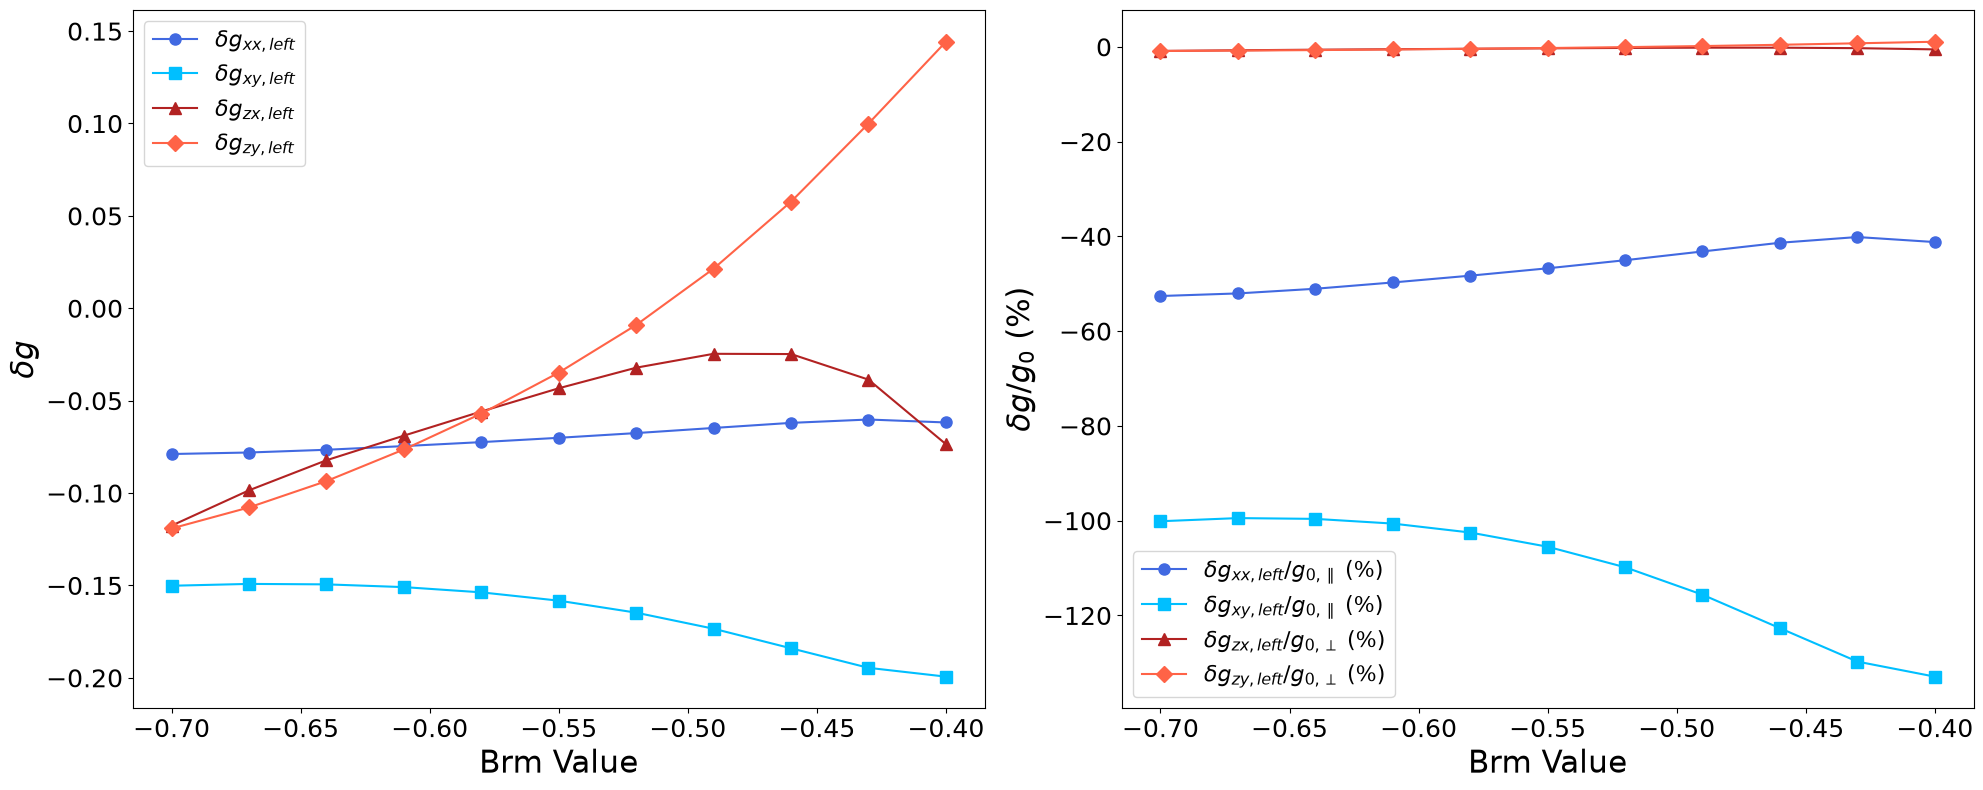

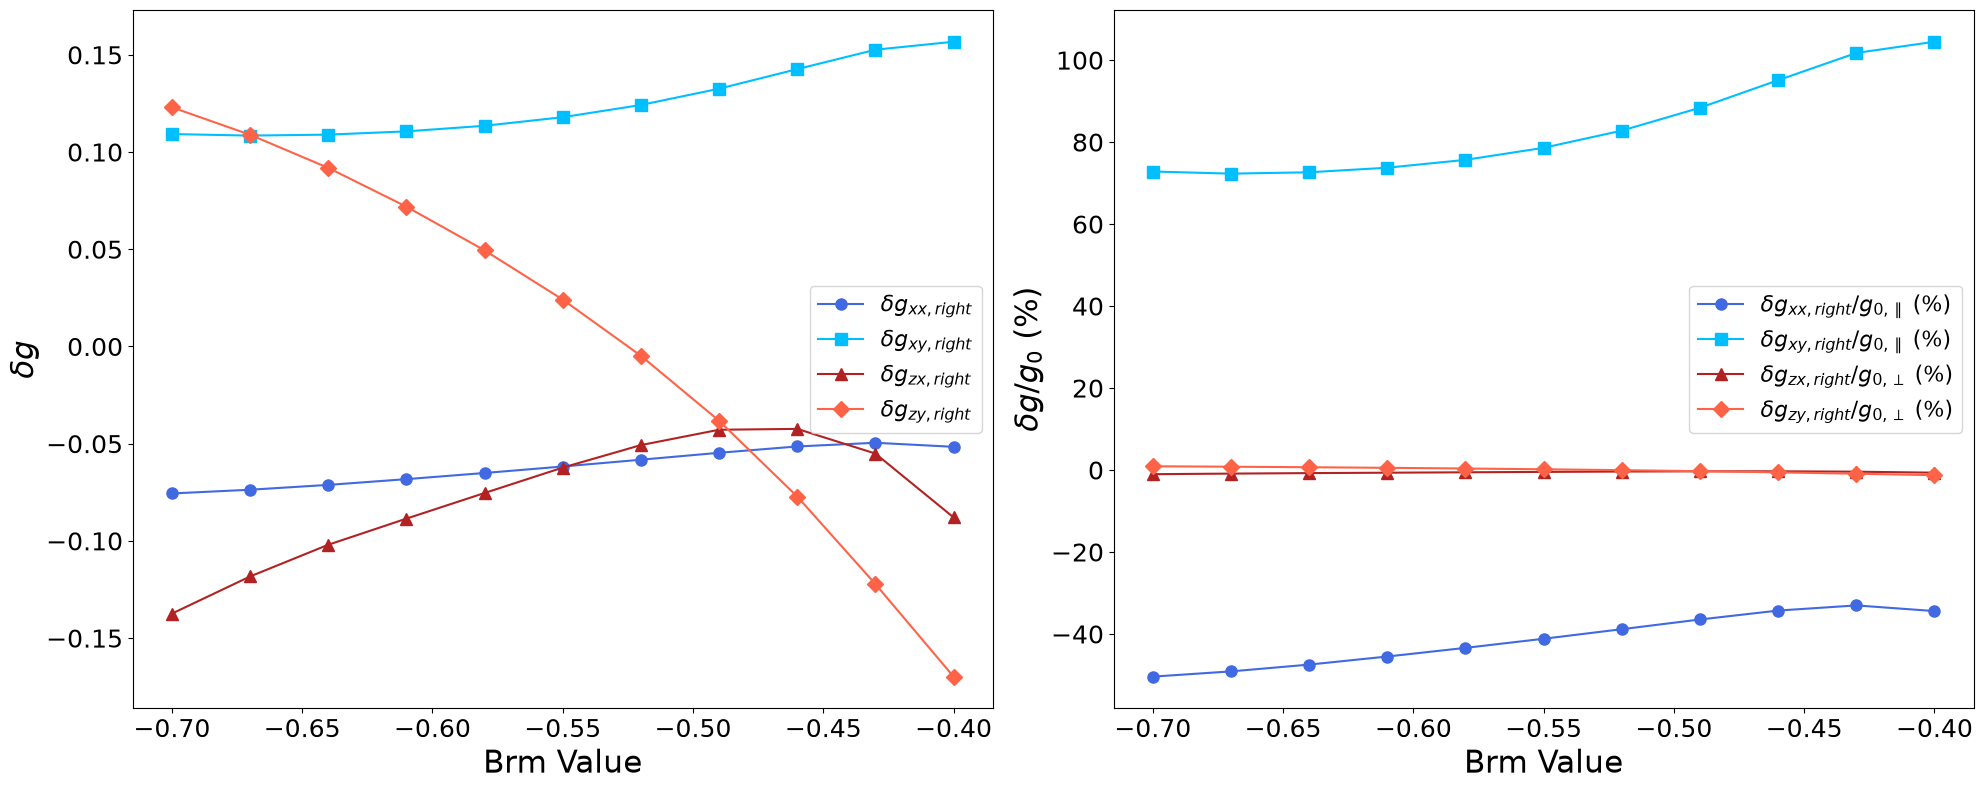

In [5]:
# Plot the per-dot g-tensor corrections (display only, not saved as PDF).
# Reads the CSVs written by the averaging cell above.
for dot_label in ["left", "right"]:
    plot_delta_g(
        dot_data_path=f"{dot_label.capitalize()}_Dot_Gaussian_Delta_G_Averages.csv",
        dot_label=dot_label
    )


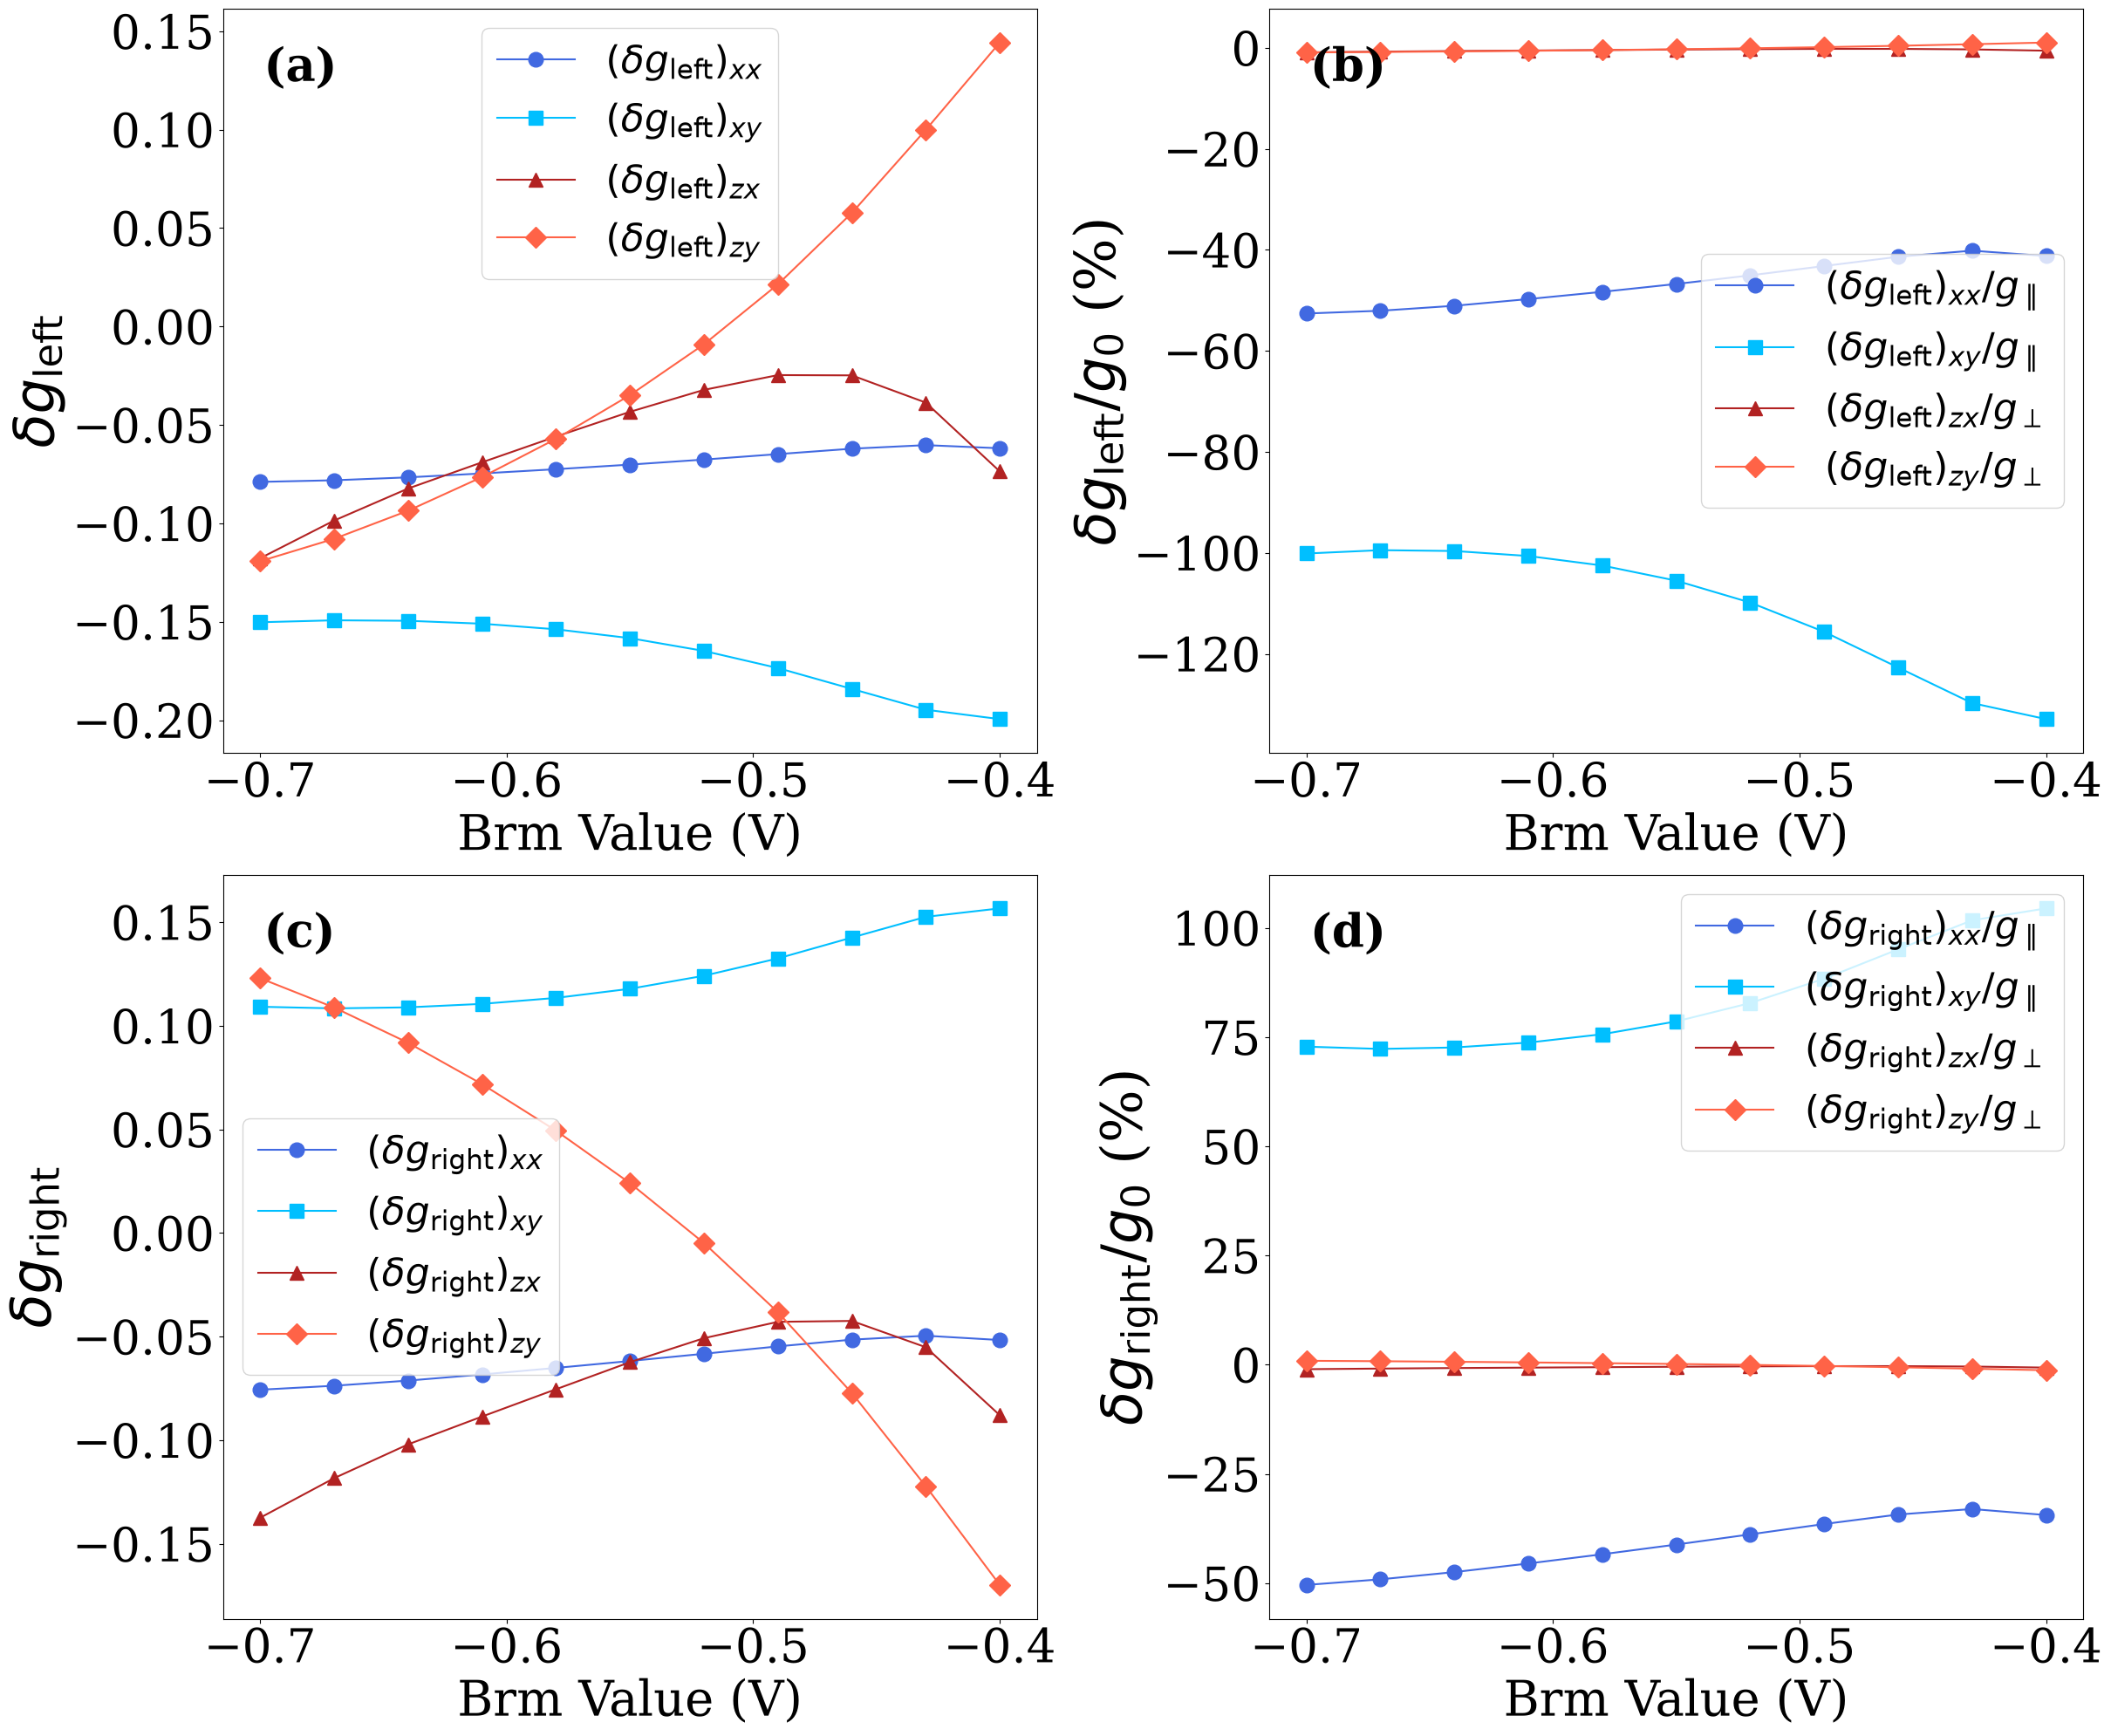

{'xx': 0    -41.205228
1    -40.143707
2    -41.353908
3    -43.187433
4    -45.038538
5    -46.743138
6    -48.297657
7    -49.733681
8    -51.059600
9    -52.044154
10   -52.591508
Name: delta_g_xx, dtype: float64, 'xy': 0    -132.914899
1    -129.737246
2    -122.690515
3    -115.626830
4    -109.828456
5    -105.499624
6    -102.500171
7    -100.613037
8     -99.622906
9     -99.457803
10   -100.121210
Name: delta_g_xy, dtype: float64, 'zx': 0    -0.544929
1    -0.286093
2    -0.183590
3    -0.182587
4    -0.238234
5    -0.320751
6    -0.413885
7    -0.510693
8    -0.609378
9    -0.729922
10   -0.871618
Name: delta_g_zx, dtype: float64, 'zy': 0     1.068491
1     0.740349
2     0.427372
3     0.158757
4    -0.066986
5    -0.258035
6    -0.422411
7    -0.566129
8    -0.692887
9    -0.798510
10   -0.882869
Name: delta_g_zy, dtype: float64}


In [6]:

# (Optional) Set a global font family for consistency
plt.rcParams.update({'font.family': 'serif'})  # You can choose 'Arial', 'Helvetica', etc.

# Define variables for axis label sizes separately
x_axis_label_size = 40  # Size for x-axis labels
y_axis_label_size = 46  # Size for y-axis labels

# Define variables for tick and legend sizes
tick_label_size = 38
legend_size = 32

# Load data for the left and right dots (local CSVs written by the averaging cell)
left_dot_data = pd.read_csv("Left_Dot_Gaussian_Delta_G_Averages.csv")
right_dot_data = pd.read_csv("Right_Dot_Gaussian_Delta_G_Averages.csv")

# Extract brm values (same for both dots)
brm_values = left_dot_data['brm']

# Define components and their properties
components = ['xx', 'xy', 'zx', 'zy']
markers = {'xx': 'o', 'xy': 's', 'zx': '^', 'zy': 'D'}
colors = {
    'xx': 'royalblue',     # inplane_color1
    'xy': 'deepskyblue',   # inplane_color2
    'zx': 'firebrick',     # outofplane_color1
    'zy': 'tomato'         # outofplane_color2
}
planes = {
    'xx': 'parallel',
    'xy': 'parallel',
    'zx': 'perpendicular',
    'zy': 'perpendicular'
}

# Bare (unperturbed) g-factor values g0 — the g-tensor itself, NOT the corrections
g0_in_plane = 0.15
g0_out_of_plane = 13.5

# Prepare δg / g0 percentages for both dots
def calculate_pct_of_g0(delta_g_values, plane_type):
    if plane_type == 'parallel':
        return (delta_g_values / g0_in_plane) * 100
    elif plane_type == 'perpendicular':
        return (delta_g_values / g0_out_of_plane) * 100

# Correction as a percentage of g0 for the left dot
left_delta_g_pct_of_g0 = {
    component: calculate_pct_of_g0(left_dot_data[f'delta_g_{component}'], planes[component])
    for component in components
}

# Correction as a percentage of g0 for the right dot
right_delta_g_pct_of_g0 = {
    component: calculate_pct_of_g0(right_dot_data[f'delta_g_{component}'], planes[component])
    for component in components
}

# Define subplot configurations
subplots_info = [
    {'row': 0, 'col': 0, 'dot': 'left', 'type': 'delta_g'},
    {'row': 0, 'col': 1, 'dot': 'left', 'type': 'pct_of_g0'},
    {'row': 1, 'col': 0, 'dot': 'right', 'type': 'delta_g'},
    {'row': 1, 'col': 1, 'dot': 'right', 'type': 'pct_of_g0'},
]

# Define subplot labels
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# Create a 2x2 grid for subplots
fig, axs = plt.subplots(2, 2, figsize=(24, 20))

# Flatten the axs array for easy iteration
axs_flat = axs.flatten()

# Iterate over each subplot configuration
for idx, subplot in enumerate(subplots_info):
    ax = axs_flat[idx]
    dot = subplot['dot']
    data_type = subplot['type']
    
    # Select the appropriate data based on dot and data_type
    if dot == 'left':
        delta_g_values = left_dot_data
        delta_g_pct_of_g0 = left_delta_g_pct_of_g0
    elif dot == 'right':
        delta_g_values = right_dot_data
        delta_g_pct_of_g0 = right_delta_g_pct_of_g0
    
    # Iterate over each component to plot
    for component in components:
        marker = markers[component]
        color = colors[component]
        plane = planes[component]
        
        if data_type == 'delta_g':
            y_data = delta_g_values[f'delta_g_{component}']
            label = f'$(\\delta g_{{\\text{{{dot}}}}})_{{{component}}}$'
            ylabel = f'$\\delta g_{{\\text{{{dot}}}}}$'
        elif data_type == 'pct_of_g0':
            y_data = delta_g_pct_of_g0[component]
            if plane == 'parallel':
                label = f'$(\\delta g_{{\\text{{{dot}}}}})_{{{component}}} / g_\\parallel$'
            else:
                label = f'$(\\delta g_{{\\text{{{dot}}}}})_{{{component}}} / g_\\perp$'
            ylabel = f'$\\delta g_{{\\text{{{dot}}}}} / g_0$ (%)'
        
        # Plot the data
        ax.plot(
            brm_values, y_data,
            marker=marker,
            color=color,
            markersize=12,
            label=label
        )
    
    # Set labels and title with separate font sizes
    ax.set_xlabel('Brm Value (V)', fontsize=x_axis_label_size)
    ax.set_ylabel(ylabel, fontsize=y_axis_label_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.legend(fontsize=legend_size)
    ax.grid(False)
    
    # Add subplot label
    ax.text(
        0.05, 0.95, subplot_labels[idx],
        transform=ax.transAxes,
        fontsize=38,
        fontweight='bold',
        va='top',
        ha='left'
    )

# Adjust layout and save the combined plot
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "Left_Right_Dot_delta_g_combined.pdf"), format="pdf")

# Display the combined plot
plt.show()
print(left_delta_g_pct_of_g0)


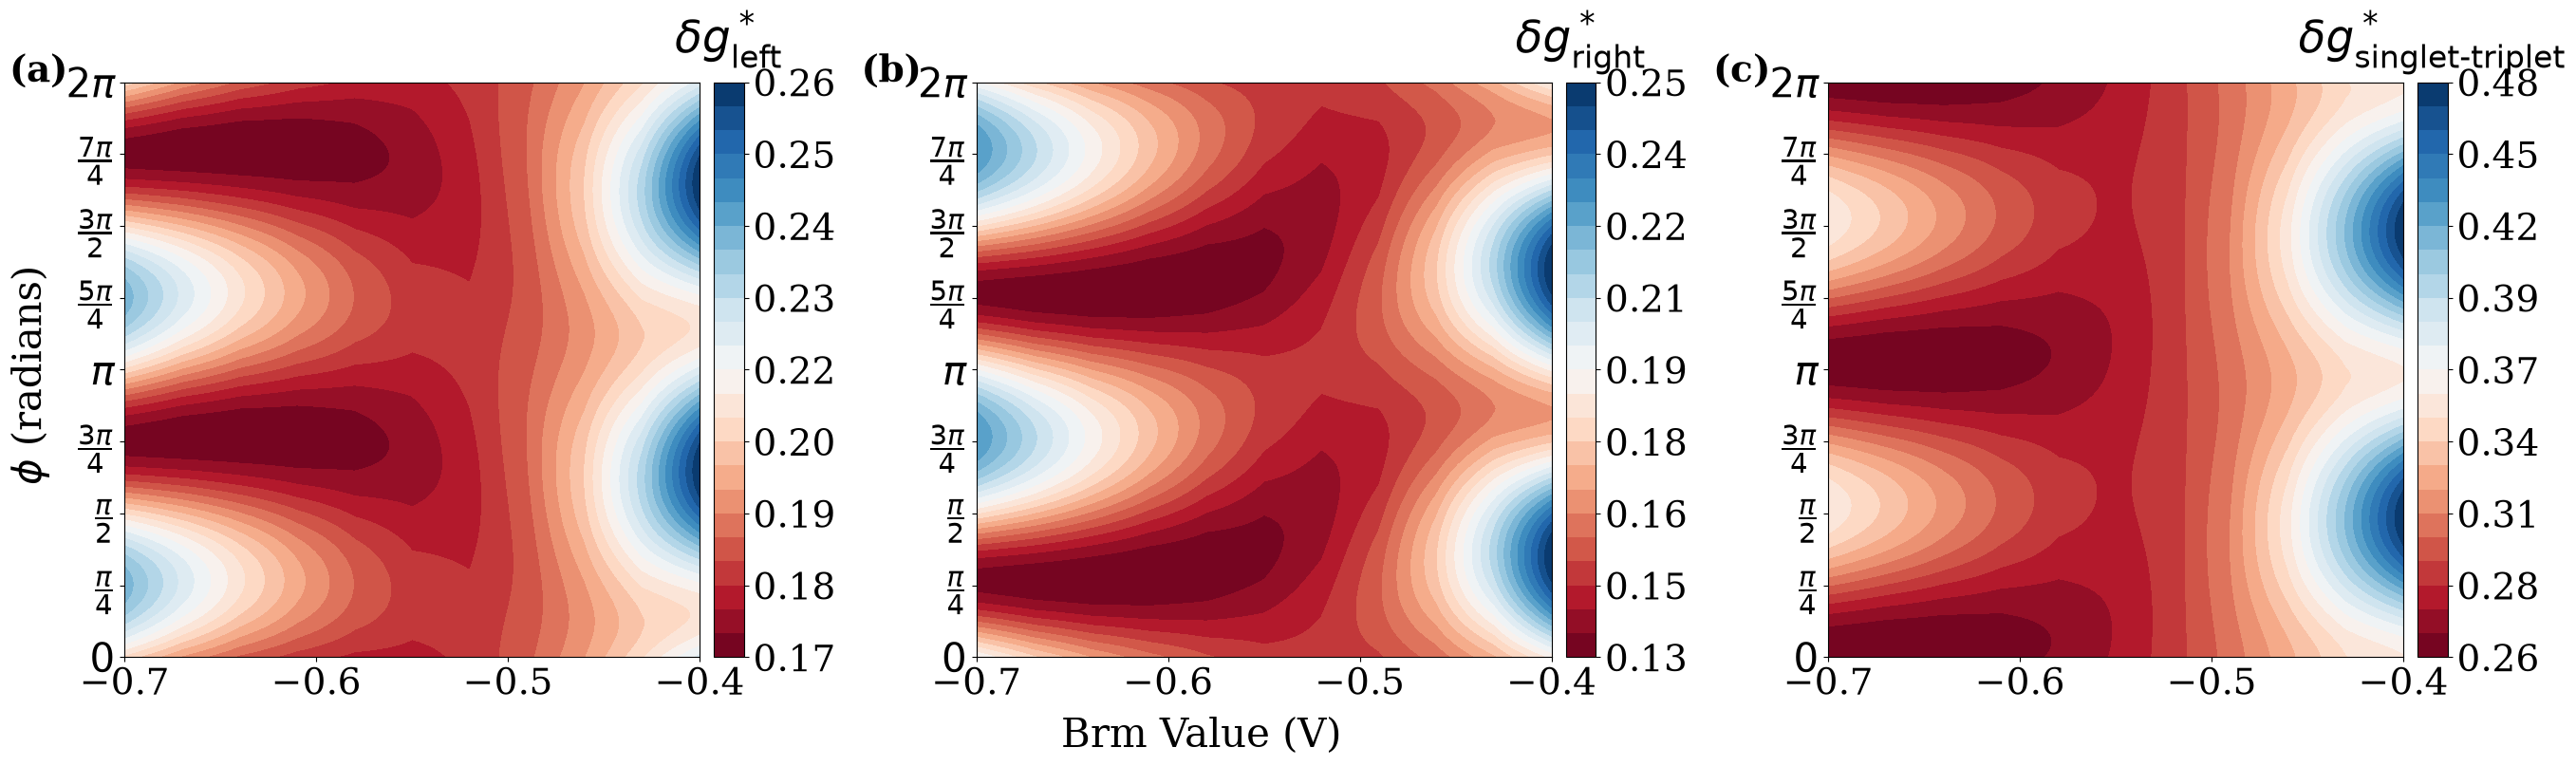

Plot saved as graph/2026-09-10/delta_g_correction_contour_comparison_3D.pdf


In [7]:
# Adjustable size variables
axis_label_size = 30
xtick_size = 28  # Size for x-axis tick labels
ytick_size = 30  # Size for y-axis tick labels
colorbar_tick_size = 28
colorbar_label_size = 34
subplot_label_size = 28

# Colormap for the contour plots (try 'RdBu', 'RdBu_r', 'afmhot', 'viridis', 'coolwarm', etc.)
colormap = 'RdBu'

# Common tick labels for all subplots
y_ticks = np.linspace(0, 2 * np.pi, 9)
y_tick_labels = [
    r'$0$', r'$\frac{\pi}{4}$', r'$\frac{\pi}{2}$', r'$\frac{3\pi}{4}$',
    r'$\pi$', r'$\frac{5\pi}{4}$', r'$\frac{3\pi}{2}$', r'$\frac{7\pi}{4}$', r'$2\pi$'
]

# Generate a shared phi_values array for all subplots
phi_values = np.linspace(0, 2 * np.pi, 1000)

def effective_delta_g(theta, phi, delta_g):
    Bx = np.sin(theta) * np.cos(phi)
    By = np.sin(theta) * np.sin(phi)
    Bz = np.cos(theta)

    delta_g_xx = delta_g['delta_g_xx']
    delta_g_xy = delta_g['delta_g_xy']
    delta_g_zx = delta_g['delta_g_zx']
    delta_g_zy = delta_g['delta_g_zy']

    delta_g_eff_x = Bx * delta_g_xx + By * delta_g_xy
    delta_g_eff_y = Bx * (-delta_g_xy) + By * delta_g_xx
    delta_g_eff_z = Bx * delta_g_zx + By * delta_g_zy

    delta_g_eff_magnitude = np.linalg.norm([delta_g_eff_x, delta_g_eff_y, delta_g_eff_z])
    return delta_g_eff_magnitude

def format_colorbar(cbar, label):
    cbar.ax.tick_params(labelsize=colorbar_tick_size)
    formatter = FormatStrFormatter('%.2f')  # Set to two decimal places
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.ax.yaxis.offsetText.set_fontsize(colorbar_tick_size)
    cbar.ax.set_title(label, fontsize=colorbar_label_size, pad=22, loc='center')

def calculate_g_correction(dot_label, delta_g_dataframes, phi_values, theta=np.pi / 2):
    Brm_values = delta_g_dataframes[dot_label]['brm']
    effective_delta_g_values = np.zeros((len(phi_values), len(Brm_values)))

    for i, brm in enumerate(Brm_values):
        delta_g = {
            'delta_g_xx': delta_g_dataframes[dot_label].loc[i, 'delta_g_xx'],
            'delta_g_xy': delta_g_dataframes[dot_label].loc[i, 'delta_g_xy'],
            'delta_g_zx': delta_g_dataframes[dot_label].loc[i, 'delta_g_zx'],
            'delta_g_zy': delta_g_dataframes[dot_label].loc[i, 'delta_g_zy'],
        }
        for j, phi in enumerate(phi_values):
            effective_delta_g_values[j, i] = effective_delta_g(theta, phi, delta_g)

    return Brm_values, effective_delta_g_values

def plot_g_correction(ax, Brm_values, effective_delta_g_values, label, colorbar_label, 
                     label_offset=(-0.2, 1.05), xtick_size=20, ytick_size=18):
    """
    Plots the g-correction as a contour plot with a colorbar.
    
    Parameters:
    - ax: Matplotlib Axes object to plot on.
    - Brm_values: Array of Brm values.
    - effective_delta_g_values: 2D array of effective δg corrections.
    - label: Subplot label (e.g., "(a)").
    - colorbar_label: Label for the colorbar.
    - label_offset: Tuple for label positioning.
    - xtick_size: Font size for x-axis ticks.
    - ytick_size: Font size for y-axis ticks.
    """
    levels = np.linspace(np.min(effective_delta_g_values), np.max(effective_delta_g_values), 25)
    contour = ax.contourf(Brm_values, phi_values, effective_delta_g_values, levels=levels, cmap=colormap)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    colorbar = plt.colorbar(contour, cax=cax)
    format_colorbar(colorbar, colorbar_label)

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_tick_labels)
    
    # Set x and y tick label sizes separately
    ax.tick_params(axis='x', which='major', labelsize=xtick_size)
    ax.tick_params(axis='y', which='major', labelsize=ytick_size)
    
    ax.set_box_aspect(1)

    ax.text(label_offset[0], label_offset[1], label, transform=ax.transAxes, 
            fontsize=subplot_label_size, fontweight='bold', va='top', ha='left')

delta_g_dataframes = {
    'left_dot': left_dot_data,
    'right_dot': right_dot_data,
}

# Difference of the δg corrections (left − right) for the singlet-triplet qubit
def calculate_st_delta_g(left_data, right_data):
    st_delta_g = pd.DataFrame()
    st_delta_g['brm'] = left_data['brm']
    st_delta_g['delta_g_xx'] = left_data['delta_g_xx'] - right_data['delta_g_xx']
    st_delta_g['delta_g_xy'] = left_data['delta_g_xy'] - right_data['delta_g_xy']
    st_delta_g['delta_g_zx'] = left_data['delta_g_zx'] - right_data['delta_g_zx']
    st_delta_g['delta_g_zy'] = left_data['delta_g_zy'] - right_data['delta_g_zy']
    return st_delta_g

# Generate the δg correction difference for the ST qubit
st_delta_g_data = calculate_st_delta_g(left_dot_data, right_dot_data)
delta_g_dataframes['singlet_triplet'] = st_delta_g_data

# Create the plot
fig, axes = plt.subplots(1, 3, figsize=(28.5, 8))

# Plot for left dot
Brm_values_left, effective_delta_g_values_left = calculate_g_correction('left_dot', delta_g_dataframes, phi_values)
plot_g_correction(
    ax=axes[0],
    Brm_values=Brm_values_left,
    effective_delta_g_values=effective_delta_g_values_left,
    label="(a)",
    colorbar_label=r"$\delta g^*_{\text{left}}$",
    xtick_size=xtick_size,  # Pass separate tick sizes
    ytick_size=ytick_size
)

# Plot for right dot
Brm_values_right, effective_delta_g_values_right = calculate_g_correction('right_dot', delta_g_dataframes, phi_values)
plot_g_correction(
    ax=axes[1],
    Brm_values=Brm_values_right,
    effective_delta_g_values=effective_delta_g_values_right,
    label="(b)",
    colorbar_label=r"$\delta g^*_{\text{right}}$",
    xtick_size=xtick_size,  # Pass separate tick sizes
    ytick_size=ytick_size
)

# Recalculate the effective δg corrections for the ST qubit
Brm_values_st, effective_delta_g_values_st = calculate_g_correction('singlet_triplet', delta_g_dataframes, phi_values)

# Plot for singlet-triplet qubit
plot_g_correction(
    ax=axes[2],
    Brm_values=Brm_values_st,
    effective_delta_g_values=effective_delta_g_values_st,
    label="(c)",
    colorbar_label=r"$\delta g^*_{\text{singlet-triplet}}$",
    xtick_size=xtick_size,  # Pass separate tick sizes
    ytick_size=ytick_size
)

# Shared labels
fig.text(0.5, 0.01, 'Brm Value (V)', ha='center', fontsize=axis_label_size)
fig.text(0.06, 0.5, r'$\phi$ (radians)', va='center', rotation='vertical', fontsize=axis_label_size)

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
output_filename = "delta_g_correction_contour_comparison_3D.pdf"
plt.savefig(os.path.join(GRAPH_DIR, output_filename), format='pdf', dpi=300)
plt.show()

print(f"Plot saved as {os.path.join(GRAPH_DIR, output_filename)}")
